## Machine Learning - CA2.1
## Matthew Riddell - D00245674

For this CA, I wish to look at Housing Prices 
I selected the following Dataset from kaggle:

https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

I will split this data into training and test data

First I wish to create a Baseline Multi-Linear Regression Model and evaluate it's performance, using House Price as the Dependant Variable 

Afterwards I would like to transform the independant variables using principle component analysis and conduct another regression on the transformed data
On this model I wish to use Grid Search to tune the number of PCA components to use in the second multi-linear regression model

And if I have enough time, I would like to try out a third model, random forest regressor, to compare between the three models to see which is strongest at predicting house prices

I will evaluate performance of each based on their R and R-Squared and Mean Squared Error values aswell as other metrics.

This code will also be uploaded to my github repo here:

https://github.com/Matthew-Riddell/Machine-Learning-CA2.1



### Question 1: Import data: 
Import relevant libraries and load the dataset.

#### Importing Packages

In [248]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import scipy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#### Loading the dataset

In [202]:
filename = 'Housing.csv' 
house_data = pd.read_csv(filename)

In [203]:
house_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#### Data Cleaning and Preparation

Replacing the yes / no values with 1 / 0

In [204]:
house_data.replace({'yes':1, 'no':0}, inplace=True)

C:\Users\Matty\AppData\Local\Temp\ipykernel_12876\1967606657.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  house_data.replace({'yes':1, 'no':0}, inplace=True)


Dropping furnishing status variabke 

In [205]:
house_data = house_data.drop("furnishingstatus", axis=1)

Checking for missing values

In [206]:
print("Number of missing values in each column:")
print(house_data.isna().sum())

Number of missing values in each column:
price              0
area               0
bedrooms           0
bathrooms          0
stories            0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
parking            0
prefarea           0
dtype: int64


In [207]:
total_missing = house_data.isna().sum().sum()
print("Total missing values in the dataset:", total_missing)

Total missing values in the dataset: 0


Checking for nonsense values

In [208]:
nonsense_values = ["?", "error", "missing", "Missing", "NaN", "nan", "N/A", "n/a", "--", " "]

Checks every column for any of the values in the nonsense values list

In [209]:
print("Checking for nonsense values:")
for col in house_data.columns:
    count = house_data[col].isin(nonsense_values).sum() 
    if count > 0:
        print(col, "has", count, "nonsense values")
    else:
        print("No nonsense values found!")

Checking for nonsense values:
No nonsense values found!
No nonsense values found!
No nonsense values found!
No nonsense values found!
No nonsense values found!
No nonsense values found!
No nonsense values found!
No nonsense values found!
No nonsense values found!
No nonsense values found!
No nonsense values found!
No nonsense values found!


In [210]:
house_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,13300000,7420,4,2,3,1,0,0,0,1,2,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0


There are no missing values or nonsense values in the dataset, data is clean, converted yes / no into binary values and dropped the furnishing status variable

### Question 2: Data Description: 
Display data attributes using data visualization
libraries/modules. 

You must use text, code, and visualization tools and comment
on Data features suitable for analysis.

Checking how many columns and rows the dataset has

In [211]:
house_data.shape

(545, 12)

Displaying the each of the variables and their object types

In [212]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   price            545 non-null    int64
 1   area             545 non-null    int64
 2   bedrooms         545 non-null    int64
 3   bathrooms        545 non-null    int64
 4   stories          545 non-null    int64
 5   mainroad         545 non-null    int64
 6   guestroom        545 non-null    int64
 7   basement         545 non-null    int64
 8   hotwaterheating  545 non-null    int64
 9   airconditioning  545 non-null    int64
 10  parking          545 non-null    int64
 11  prefarea         545 non-null    int64
dtypes: int64(12)
memory usage: 51.2 KB


#### The dataset I am using has the following variables:


area: the area of the house in square feet	

bedrooms: the number of bedrooms in the house	

bathrooms: the number of bathrooms in the house	

stories: the number of stories the house has

mainroad: yes/no if the house is connected to a main road	

guestroom:  yes/no if the house has a guest room	

basement:  yes/no if the house has a basement

hotwaterheating:  yes/no if the house has a hot water heater

airconditioning:  yes/no if the house has air conditioning

parking: number of parking spaces the house has

prefarea:  yes/no if the house is in a preferred area

In [213]:
house_data.head(15)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,13300000,7420,4,2,3,1,0,0,0,1,2,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0
5,10850000,7500,3,3,1,1,0,1,0,1,2,1
6,10150000,8580,4,3,4,1,0,0,0,1,2,1
7,10150000,16200,5,3,2,1,0,0,0,0,0,0
8,9870000,8100,4,1,2,1,1,1,0,1,2,1
9,9800000,5750,3,2,4,1,1,0,0,1,1,1


#### Summary statistics of each variable

In [214]:

house_data.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


#### Scatterplots of each numerical variable

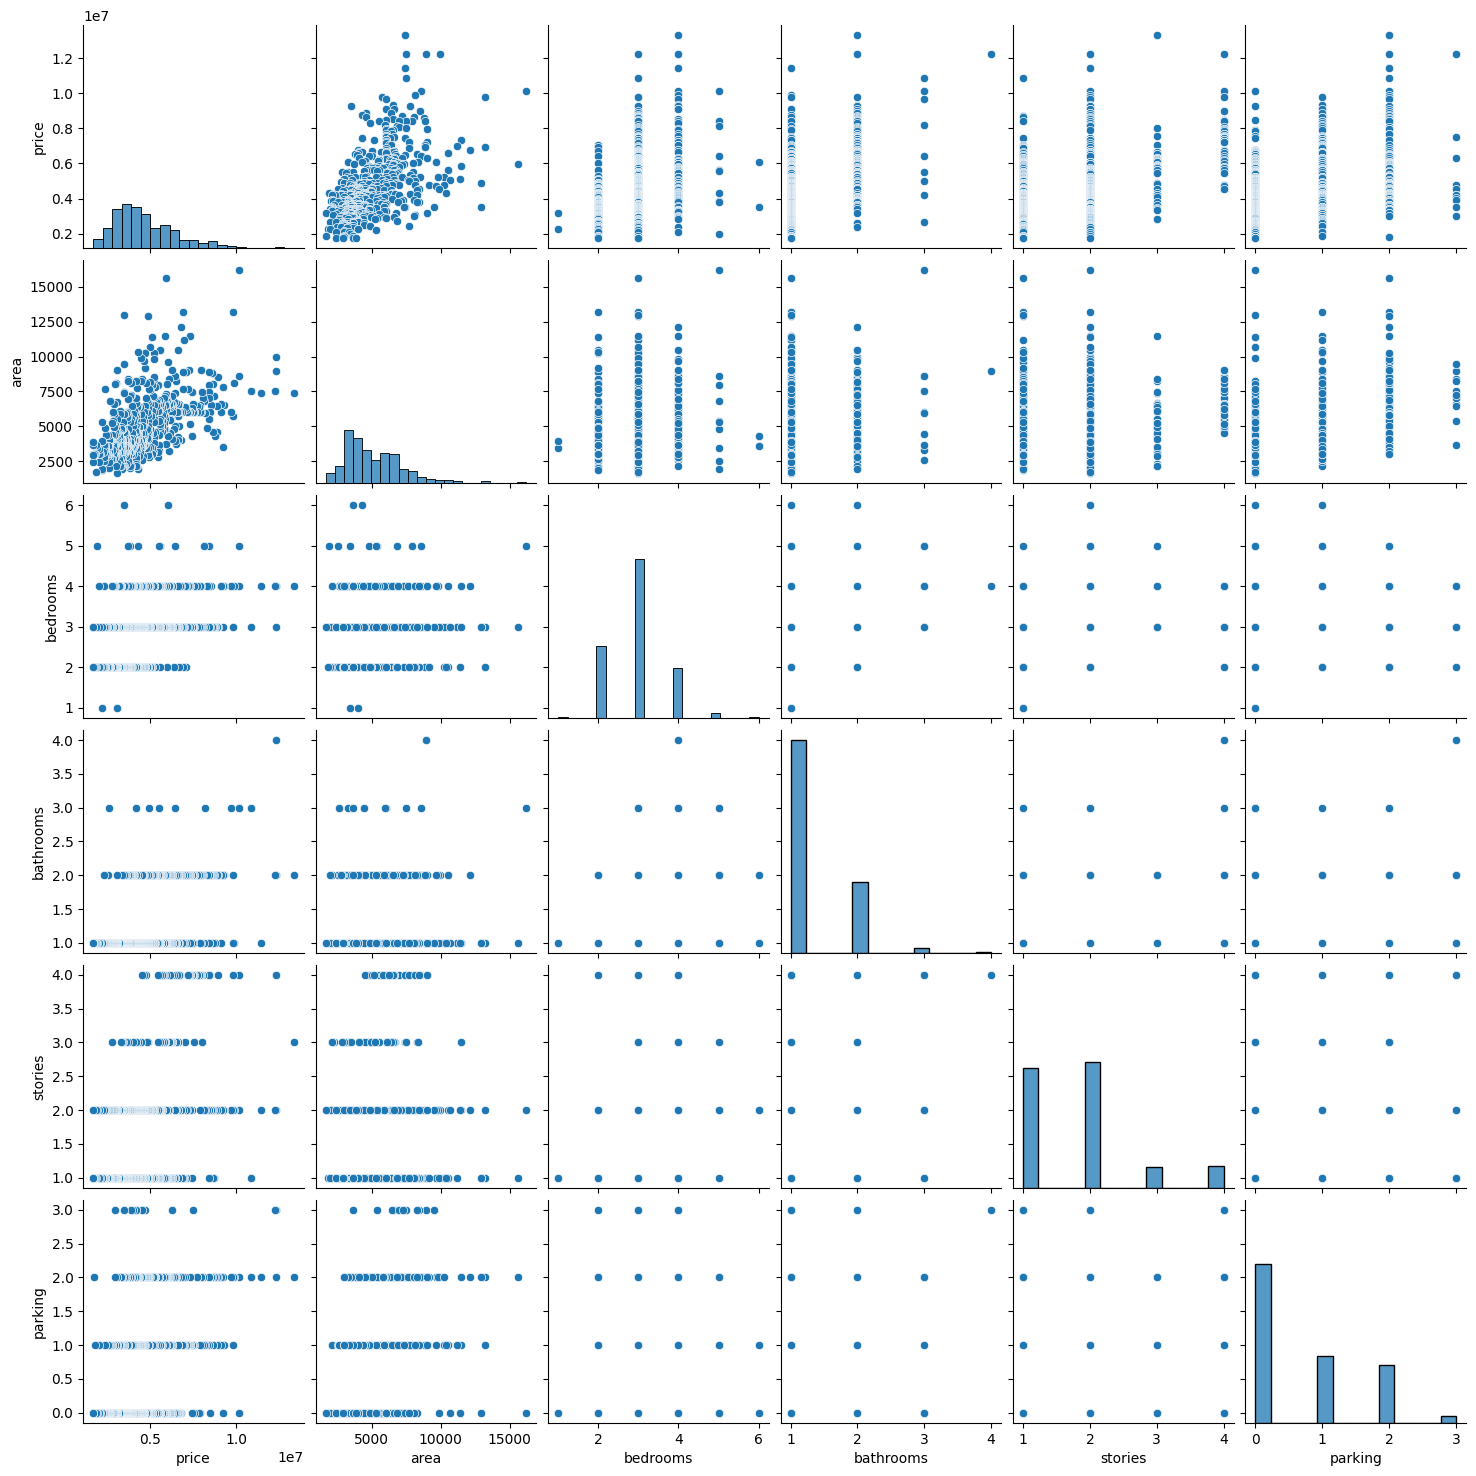

In [215]:
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

sns.pairplot(house_data[num_cols])
plt.show()

#### Scatterplots with prefarea highlighted

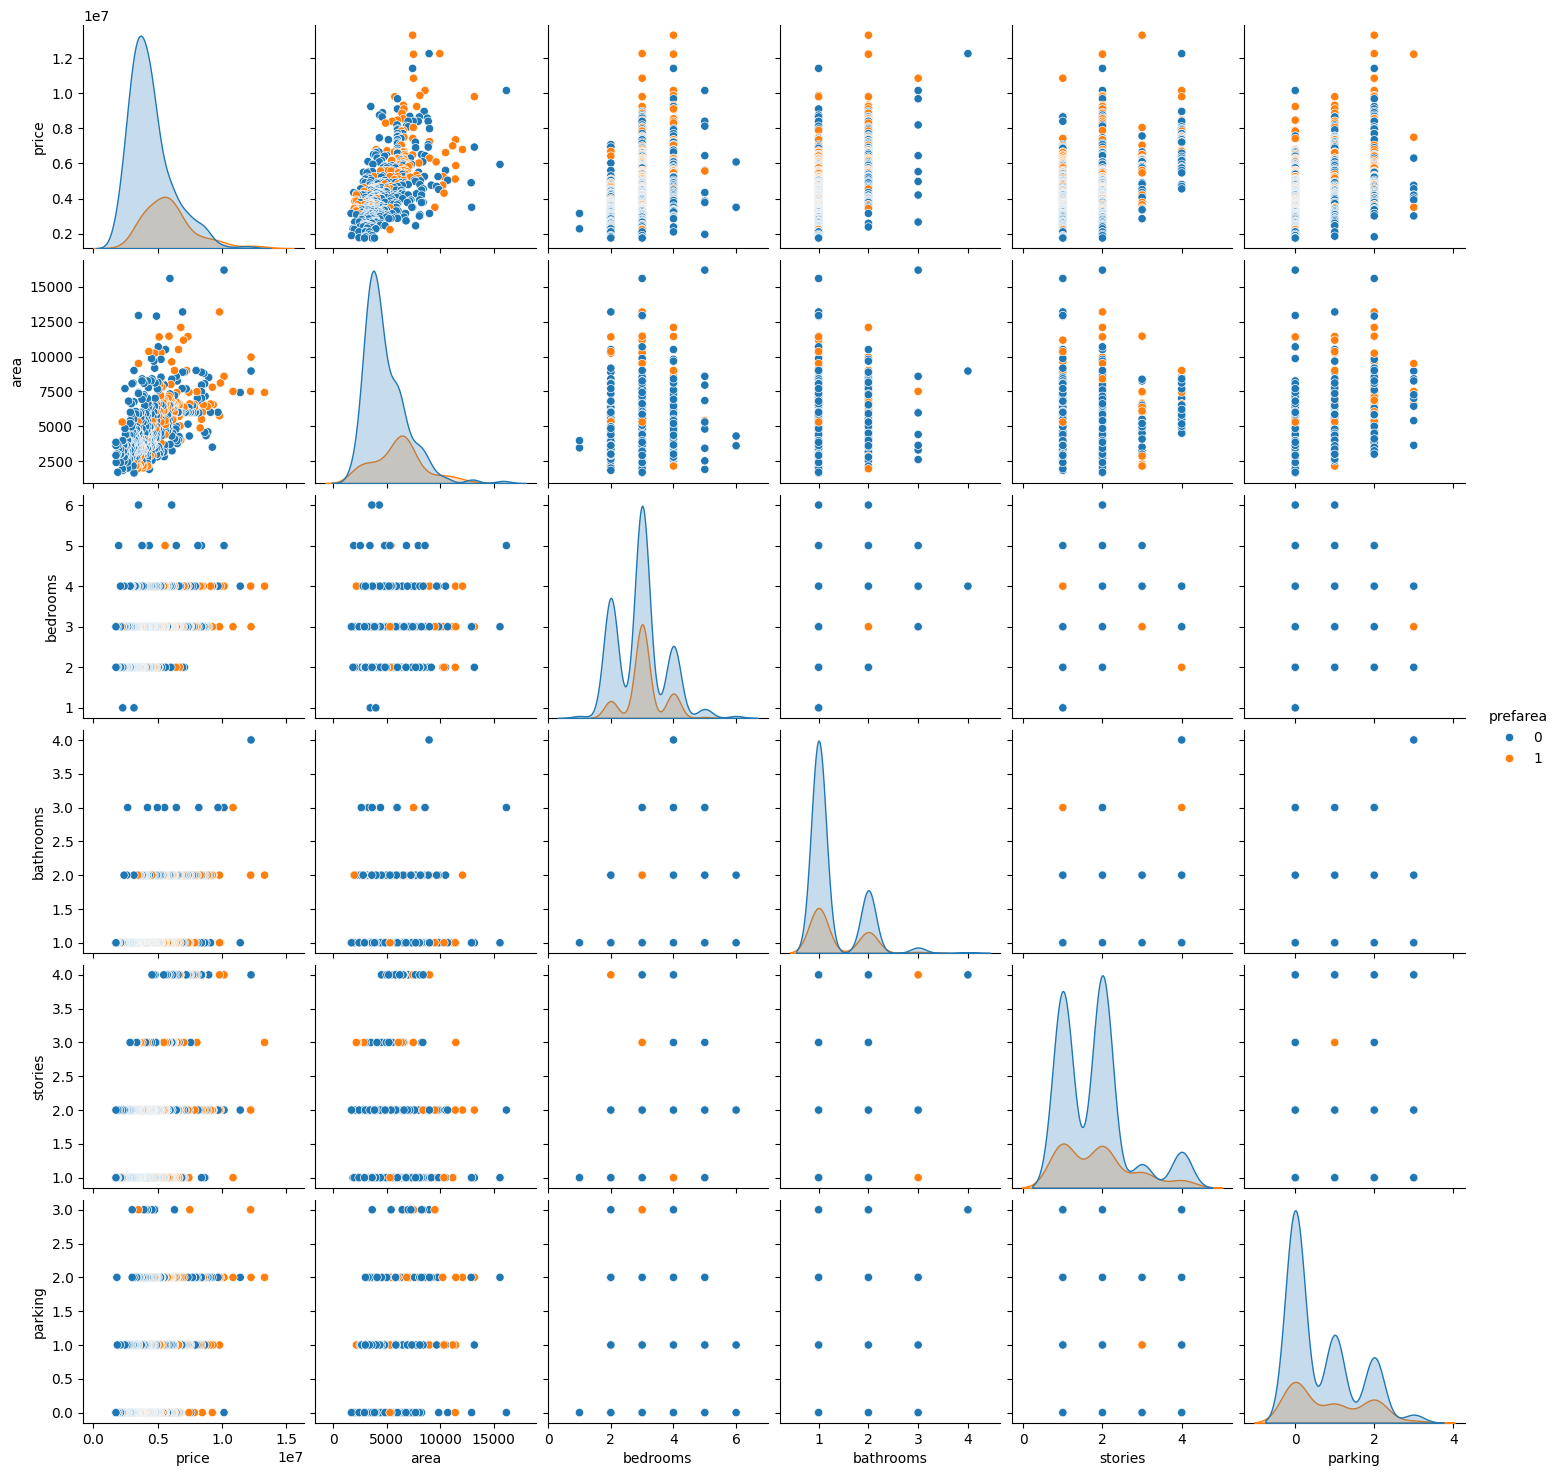

In [216]:
sns.pairplot(house_data[num_cols + ['prefarea']], hue='prefarea')
plt.show()

Most of these variables appear to be non-linear

Area is strongly correlated with Price and Bedroom and Stories also have looser correlations

#### Pearson correlations between each numerical variable

In [217]:
house_data[num_cols].corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


#### Correlation heatmap

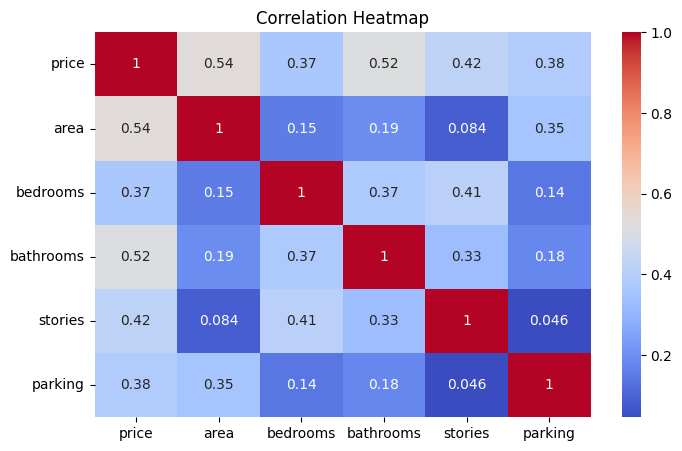

In [218]:
plt.figure(figsize=(8,5))
sns.heatmap(house_data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

All the independant variables appear to be uncorrelated which is good news for avoiding multi-collinearity


#### Boxplots of house prices vs Prefered Area

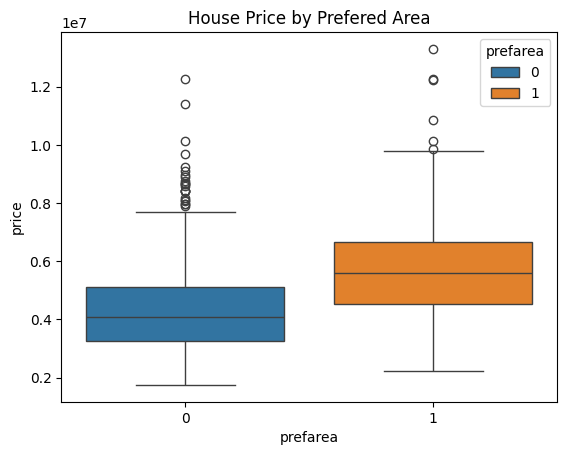

In [219]:
sns.boxplot(x='prefarea', y='price', data=house_data, hue='prefarea')
plt.title("House Price by Prefered Area")
plt.show()

#### Boxplots of house prices vs Guest Room

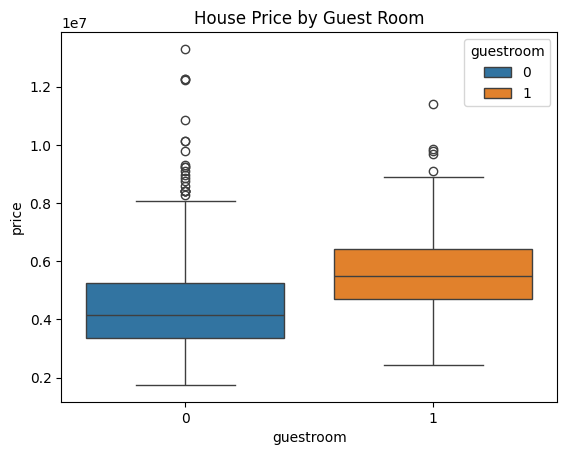

In [220]:
sns.boxplot(x='guestroom', y='price', data=house_data, hue='guestroom')
plt.title("House Price by Guest Room")
plt.show()

#### Boxplots of house prices vs Basement

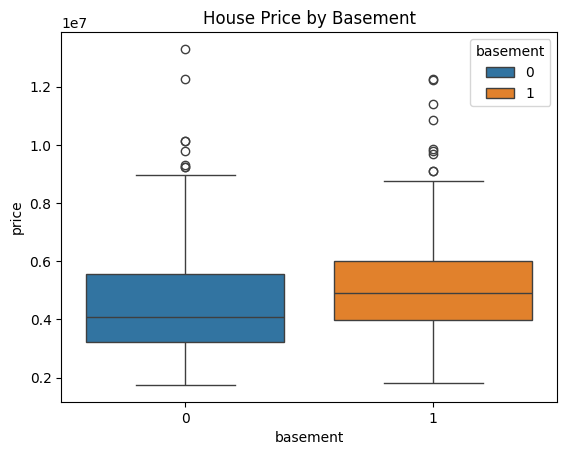

In [221]:
sns.boxplot(x='basement', y='price', data=house_data, hue='basement')
plt.title("House Price by Basement")
plt.show()

#### Boxplots of house prices vs Main Road

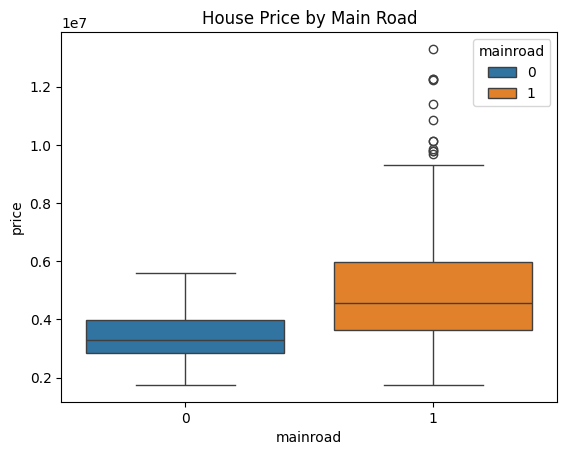

In [222]:
sns.boxplot(x='mainroad', y='price', data=house_data, hue='mainroad')
plt.title("House Price by Main Road")
plt.show()

#### Boxplots of house prices vs Hotwater Heating

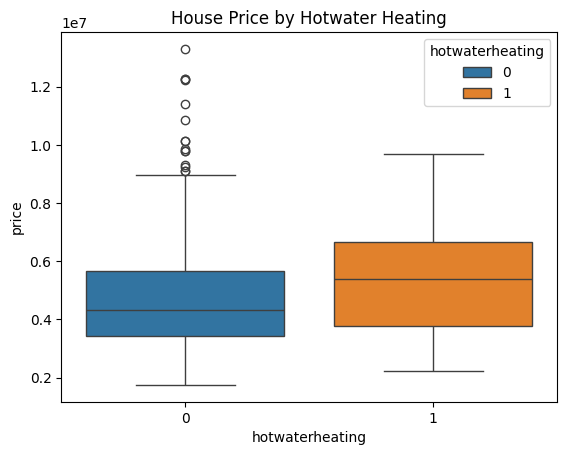

In [223]:
sns.boxplot(x='hotwaterheating', y='price', data=house_data, hue='hotwaterheating')
plt.title("House Price by Hotwater Heating")
plt.show()

#### Boxplots of house prices vs Air Conditioning

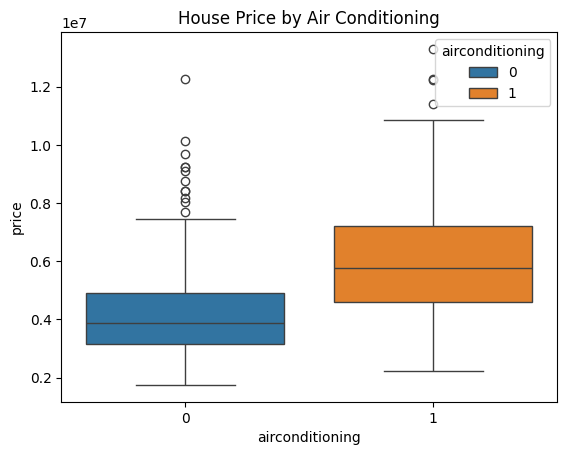

In [224]:
sns.boxplot(x='airconditioning', y='price', data=house_data, hue='airconditioning')
plt.title("House Price by Air Conditioning")
plt.show()

From looking at the boxplots

Each of the binary variables show an increase in price whenever the value is set to 1 

The numerical variables have some correlations with but they are much weaker with area and number of bedrooms being the strongest

For the Multi-linear regression I may consider dropping some of the weakest correlated numerical and binary variables but for now I want to try it with all variables included

### Question 3: ML Modeling: 
Create / select a baseline ML model. 

Determine the impact of selected ML model/models and interpret the best model with parameters.

#### Splitting Price into Y from the independant variables which remain as X

In [225]:
X = house_data.drop('price', axis=1)
Y = house_data['price']

#### Splitting the data into training and test sets with a 20% split for the test data

In [226]:
# Code adapted from week 4 parametric tuning activity
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

#### Scaling the data, models such as PCA are highly sensitive to scaling

In [227]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Creating the linear regression model

fitting the model

In [228]:
X_train_const = sm.add_constant(X_train)
model_lr = sm.OLS(Y_train, X_train_const).fit()

#### Predictions of Y based on the test data

In [229]:
# Code adapted from week 4 parametric tuning activity
X_test_const = sm.add_constant(X_test)
Y_pred = model_lr.predict(X_test_const)

#### Model summary

In [230]:
model_lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     81.21
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.48e-97
Time:                        02:50:46   Log-Likelihood:                -6640.6
No. Observations:                 436   AIC:                         1.331e+04
Df Residuals:                     424   BIC:                         1.335e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -7.243e+04   2.47e+05     -0.293      0.770   -5.59e+05    4.14e+05
area              237.7105     25.144      9.454      0.000     188.288     287.133
bedrooms         7.848e+04   7.61e+04      1.031      0.303   -7.11e+04    2.28e+05
bathrooms        1.109e+06   1.15e+05      9.608      0.000    8.82e+05    1.34e+06
stories          4.269e+05   6.92e+04      6.170      0.000    2.91e+05    5.63e+05
mainroad         4.127e+05    1.5e+05      2.750      0.006    1.18e+05    7.08e+05
guestroom        2.436e+05   1.42e+05      1.716      0.087   -3.54e+04    5.23e+05
basement          4.35e+05   1.18e+05      3.690      0.000    2.03e+05    6.67e+05
hotwaterheating  7.123e+05   2.25e+05      3.165      0.002     2.7e+05    1.15e+06
airconditioning  8.084e+05   1.18e+05      6.876      0.000    5.77e+05    1.04e+06
parking          2.474e+05    6.2e+04      3.990      0.000    1.26e+05    3.69e+05
prefarea         6.368e+05   1.22e+05      5.211      0.000    3.97e+05    8.77e+05
==============================================================================
Omnibus:                       72.064   Durbin-Watson:                   1.893
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              187.623
Skew:                           0.810   Prob(JB):                     1.81e-41
Kurtosis:                       5.775   Cond. No.                     3.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### R-squared and RMSE 

In [231]:
# Code adapted from week 4 parametric tuning activity
r2_model_lr = r2_score(Y_test, Y_pred)
rmse_model_lr = np.sqrt(mean_squared_error(Y_test, Y_pred))

#### Displaying the R-squared and RMSE from the predictions

In [232]:
print("Linear Regression R2:", r2_model_lr)
print("Linear Regression RMSE:", rmse_model_lr)

Linear Regression R2: 0.64372960866141
Linear Regression RMSE: 1341936.5557726547


### Creating the PCA LInear Regression Model

using PCA to transform the training and testing data

In [233]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### Scree Plot showing components and their explained variance

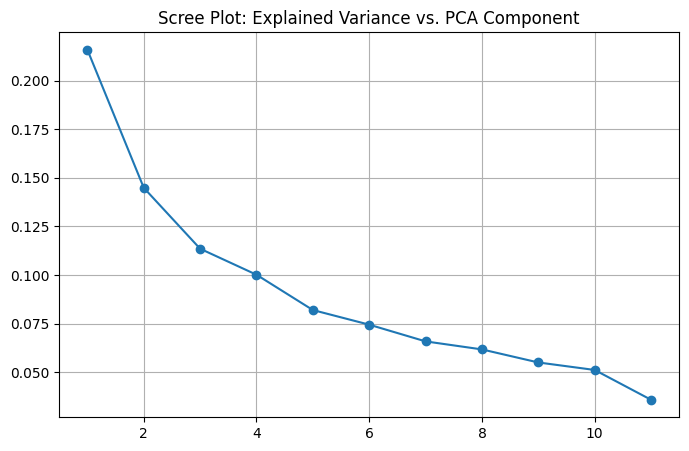

In [234]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(X.columns) + 1), pca.explained_variance_ratio_, marker='o')
plt.title('Scree Plot: Explained Variance vs. PCA Component')
plt.grid(True)
plt.show()

### Using Grid Search for Hyper Parameter Tuning (finding the best set of PCA components)

In [235]:
# Code adapted from week 4 parametric tuning activity
param_grid = {'n_components':[2,3,4,5,6,7,8]}
grid_search = GridSearchCV(estimator=pca, param_grid=param_grid, cv=5)
grid_search.fit(X_train_scaled)


print("Best number of components:", grid_search.best_params_)

Best number of components: {'n_components': 6}


### Creating a new PCA with the tuned number of components

In [236]:
model_pca = PCA(n_components=grid_search.best_params_['n_components'])

X_train_pca = model_pca.fit_transform(X_train_scaled)
X_test_pca = model_pca.transform(X_test_scaled)

### Fitting the model

In [237]:
X_train_pca_const = sm.add_constant(X_train_pca)
model_pca = sm.OLS(Y_train, X_train_pca_const).fit()

#### Predictions of Y based on the test data

In [238]:
# Code adapted from week 4 parametric tuning activity
X_test_pca_const = sm.add_constant(X_test_pca)
Y_pred_pca = model_pca.predict(X_test_pca_const)

#### Model Summary

In [239]:
model_pca.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     128.5
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.46e-92
Time:                        02:50:46   Log-Likelihood:                -6663.5
No. Observations:                 436   AIC:                         1.334e+04
Df Residuals:                     429   BIC:                         1.337e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.707e+06   5.07e+04     92.848      0.000    4.61e+06    4.81e+06
x1          9.069e+05   3.29e+04     27.577      0.000    8.42e+05    9.72e+05
x2         -2.177e+04   4.02e+04     -0.542      0.588   -1.01e+05    5.72e+04
x3         -7.065e+04   4.54e+04     -1.557      0.120    -1.6e+05    1.85e+04
x4          1.305e+05   4.83e+04      2.701      0.007    3.55e+04    2.25e+05
x5         -9439.5200   5.34e+04     -0.177      0.860   -1.14e+05    9.55e+04
x6         -3.821e+04    5.6e+04     -0.682      0.496   -1.48e+05    7.19e+04
==============================================================================
Omnibus:                       42.975   Durbin-Watson:                   1.913
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               81.695
Skew:                           0.585   Prob(JB):                     1.82e-18
Kurtosis:                       4.768   Cond. No.                         1.70
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Display R-Squared and RMSE values of the model performance on test data

In [240]:
# Code adapted from week 4 parametric tuning activity
r2_pca = r2_score(Y_test, Y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(Y_test, Y_pred_pca))

In [241]:
print("PCA Model R2:", r2_pca)
print("PCA Model RMSE:", rmse_pca)

PCA Model R2: 0.6374186974488816
PCA Model RMSE: 1353769.7971816477


### Creating a Random Forest Regressor Model

#### Fitting the model

In [260]:
# Code adapted from week 4 parametric tuning activity
rf_model = RandomForestRegressor()
rf_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### Predictions of Y based on the test data

In [261]:
# Code adapted from week 4 parametric tuning activity
Y_pred_rf = rf_model.predict(X_test)

#### Displaying the R-Squared and RMSE values based on model performance on the test data

In [262]:
# Code adapted from week 4 parametric tuning activity
r2_rf = r2_score(Y_test, Y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))

In [263]:
print("Random Forest R2:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R2: 0.61293485236197
Random Forest RMSE: 1398730.8456790478


### Question 4: Evaluate the performance of the model in terms of evaluation metrics.
Provide a report on the performance comparison and explain the reasons for the
following.
- Selection of model/models
- Selection of hyper-parameters
- Tuning of hyper-parameters
- Interpretation of the loss function (if any)
- Accuracy of your model during training and testing
- Submit the code with the final optimized model

Prepare a short report summarizing the steps taken to solve the problem. 

Your
report should clearly explain the approach, the models used, and the challenges
encountered. 

Focus on clarity and conciseness, and follow academic writing standards.

### Evaluating the Multi-Linear Regression Model
#### Evaluation of the model on training data

In [245]:
model_lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     81.21
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.48e-97
Time:                        14:23:54   Log-Likelihood:                -6640.6
No. Observations:                 436   AIC:                         1.331e+04
Df Residuals:                     424   BIC:                         1.335e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -7.243e+04   2.47e+05     -0.293      0.770   -5.59e+05    4.14e+05
area              237.7105     25.144      9.454      0.000     188.288     287.133
bedrooms         7.848e+04   7.61e+04      1.031      0.303   -7.11e+04    2.28e+05
bathrooms        1.109e+06   1.15e+05      9.608      0.000    8.82e+05    1.34e+06
stories          4.269e+05   6.92e+04      6.170      0.000    2.91e+05    5.63e+05
mainroad         4.127e+05    1.5e+05      2.750      0.006    1.18e+05    7.08e+05
guestroom        2.436e+05   1.42e+05      1.716      0.087   -3.54e+04    5.23e+05
basement          4.35e+05   1.18e+05      3.690      0.000    2.03e+05    6.67e+05
hotwaterheating  7.123e+05   2.25e+05      3.165      0.002     2.7e+05    1.15e+06
airconditioning  8.084e+05   1.18e+05      6.876      0.000    5.77e+05    1.04e+06
parking          2.474e+05    6.2e+04      3.990      0.000    1.26e+05    3.69e+05
prefarea         6.368e+05   1.22e+05      5.211      0.000    3.97e+05    8.77e+05
==============================================================================
Omnibus:                       72.064   Durbin-Watson:                   1.893
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              187.623
Skew:                           0.810   Prob(JB):                     1.81e-41
Kurtosis:                       5.775   Cond. No.                     3.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Evaluation of the model's performance on training data

R-squared = 0.678 meaning that the model explains 67.8% of variance in Price

R-squared ajusted is almost identical at 0.670 confirming no overfitting of the model

P-value for co-efficent Area is extremely low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent Bedrooms is very high at 0.303 suggesting that it is a redundant, insignificant variable

P-value for co-efficent Bathrooms is extremely low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent Stories is extremely low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent Mainroad is low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent Guestroom is high ( > 0.05 ) showing that it is somewhat redundant

P-value for co-efficent Basement is extremely low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent Hotwaterheating is extremely low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent Airconditioning is extremely low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent Parking is extremely low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent Prefarea is extremely low ( < 0.05 ) showing that it is highly significant

### Evaluating the PCA Transformed Multi-Linear Regression Model
#### Evaluation of the model on training data

In [246]:
model_pca.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     128.5
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.46e-92
Time:                        14:24:02   Log-Likelihood:                -6663.5
No. Observations:                 436   AIC:                         1.334e+04
Df Residuals:                     429   BIC:                         1.337e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.707e+06   5.07e+04     92.848      0.000    4.61e+06    4.81e+06
x1          9.069e+05   3.29e+04     27.577      0.000    8.42e+05    9.72e+05
x2         -2.177e+04   4.02e+04     -0.542      0.588   -1.01e+05    5.72e+04
x3         -7.065e+04   4.54e+04     -1.557      0.120    -1.6e+05    1.85e+04
x4          1.305e+05   4.83e+04      2.701      0.007    3.55e+04    2.25e+05
x5         -9439.5200   5.34e+04     -0.177      0.860   -1.14e+05    9.55e+04
x6         -3.821e+04    5.6e+04     -0.682      0.496   -1.48e+05    7.19e+04
==============================================================================
Omnibus:                       42.975   Durbin-Watson:                   1.913
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               81.695
Skew:                           0.585   Prob(JB):                     1.82e-18
Kurtosis:                       4.768   Cond. No.                         1.70
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Evaluation of the model's performance on training data

R-squared = 0.642 meaning that the model explains 64.2% of variance in Price

R-squared ajusted is almost identical at 0.637 confirming no overfitting of the model

P-value for co-efficent PC1 is extremely low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent PC2 is very high at 0.588 suggesting that it is a redundant, insignificant variable

P-value for co-efficent PC3 is high at 0.120 showing that it is redundant

P-value for co-efficent PC4 is extremely low ( < 0.05 ) showing that it is highly significant

P-value for co-efficent PC5 is very high at 0.860 suggesting that it is a redundant, insignificant variable

P-value for co-efficent PC6 is very high at 0.496 suggesting that it is a redundant, insignificant variable

### Random Forest Test Results:

- R-Squared 0.613
- RMSE 1398730.85

The model explains 61.3% of variance 

RMSE very high

### Evaluating all three models based on the performance from the test data

In [264]:
print("Linear Regression R2:", r2_model_lr)
print("Linear Regression RMSE:", rmse_model_lr)

print("PCA Model R2:", r2_pca)
print("PCA Model RMSE:", rmse_pca)

print("Random Forest R2:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

Linear Regression R2: 0.64372960866141
Linear Regression RMSE: 1341936.5557726547
PCA Model R2: 0.6374186974488816
PCA Model RMSE: 1353769.7971816477
Random Forest R2: 0.61293485236197
Random Forest RMSE: 1398730.8456790478


### Multi-Linear Regression Model: (Training)

- R-Squared 0.678
- Adj. R-Squared 0.670
- AIC 13310
- BIC 13350
- Number of predictors 11

### PCA Transformed Multi-Linear Regression Model: (Training)

- R-Squared 0.642
- Adj. R-Squared 0.637
- AIC 13340
- BIC 13370
- Number of predictors 6

### Multi-Linear Regression Model: (Testing)

- R-Squared 0.644
- RMSE 1341936.56

### PCA Transformed Multi-Linear Regression Model: (Testing)

- R-Squared 0.637
- RMSE 1353769.80

### Random Forest Regression Model: (Testing)

- R-Squared 0.613
- RMSE 1398730.85

Both models performed slightly better on the training data than on the testing data R-squared in the model summary is higher than the R-Squared from the predictions

The Linear Regression model performed slightly better

The PCA transformed Linear Regression model performed more or less the same

This is because PCA is designed for maximum variance and for eliminating multi-collinearity and most importantly, dimensionality reduction

Since the indpendant variables where already uncorrelated, we are no seeing PCA at its greatest potential

AIC and BIC for the PCA model are slightly higher than the baseline LR model, meaning that while there was a reduction of complexity, the model still fails to capture a good fit compared to the regular LR model

So while it transformed the data, it does so in a way that simplifies existing patterns meaning it's more or less the same

The RMSE is slightly higher for the PCA model meaning that it is slightly less accurate with a higher prediction error

The random forest model perfomed the poorest with an R-Squared value of 0.613 and the highest RMSE value so far

This may be due to overfitting or the fact that the data is already mostly linear, and the random forest overcomplicates that, it also may be due to it being a small dataset in general

Nevertheless it was insightful too see how all three models performed

In summary:

Multi-Linear Regression Model performs slightly better than the PCA transformed Multi-Linear Regression Model and the Random Forest Regression Model overall

Further write-up on the results in my report submission

## Matthew Riddell - Machine Learning Report: